In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('../data/rna_data.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,0,TCGA-3C-AALI,-0.641192,-4.928226,0.095465,0.098128,-0.541978,-0.32291,-0.044694,-0.148846,...,0.312922,0.079683,0.475267,1.99661,0.161423,0.273714,0.644673,-0.428695,0.068667,-0.043812
1,1,TCGA-3C-AALJ,1.082808,-4.623726,-0.531035,0.484028,-0.183678,-0.91901,0.261106,0.687754,...,-0.748878,-0.656117,-0.216733,0.21081,0.101023,0.660514,1.295073,0.915105,0.168567,0.047788
2,2,TCGA-3C-AALK,0.121608,-2.881526,-0.531035,0.179128,0.039222,-0.45491,0.180306,0.775554,...,0.415422,-0.178417,-0.211233,-1.28139,0.108023,1.132814,0.496773,0.240105,3.099767,0.112888
3,3,TCGA-4H-AAAK,0.420208,-3.282726,-0.531035,-0.020972,-0.117978,-0.55781,-0.173794,-1.079146,...,0.685222,-0.698717,-0.484233,-1.28139,-0.223577,1.222714,0.225573,-0.301995,0.200067,-0.080212
4,4,TCGA-5L-AAT0,0.474808,-2.775226,-0.531035,0.246028,-0.378378,-0.83081,0.338906,1.247754,...,-0.748878,0.589083,0.726267,-1.28139,-0.622577,1.212114,0.976973,0.301305,2.843667,0.138388


In [ ]:
len(df.columns)

In [3]:
df['location'] = df['Unnamed: 0'].str.split('-').str[1]
n_unique_locations = df['location'].nunique()
location_counts = df['location'].value_counts()

In [5]:
n_unique_locations, location_counts

(37,
 location
 BH    116
 A2     87
 E2     78
 D8     71
 A8     67
 AR     55
 B6     44
 E9     44
 AO     42
 C8     40
 EW     35
 AC     32
 AN     30
 A7     26
 LL     16
 GM     16
 OL     13
 S3     10
 A1      9
 LD      5
 AQ      5
 PL      3
 PE      3
 3C      3
 5L      2
 XX      2
 WT      2
 Z7      2
 HN      2
 5T      1
 4H      1
 GI      1
 JL      1
 OK      1
 UL      1
 UU      1
 W8      1
 Name: count, dtype: int64)

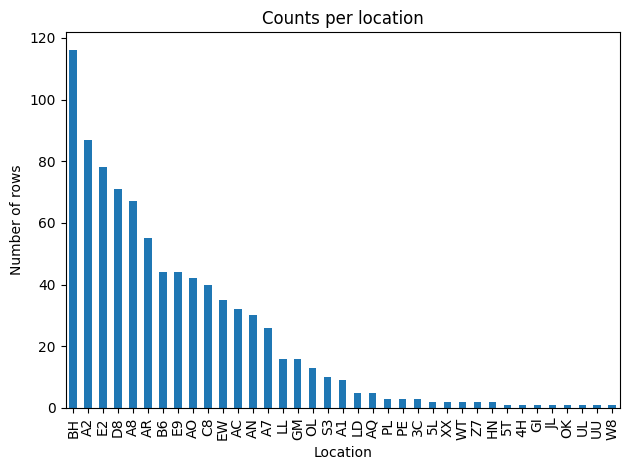

In [6]:
import matplotlib.pyplot as plt

plt.figure()
location_counts.plot(kind="bar")
plt.xlabel("Location")
plt.ylabel("Number of rows")
plt.title("Counts per location")
plt.tight_layout()
plt.show()


## Existing clinical splits

In [2]:
import pandas as pd
from pathlib import Path

# folder główny z foldami
base_dir = Path("/scratch/2370352/my-research/repo/src/data/files/tcga_brca/splits")  # <-- zmień na swoją ścieżkę

# iterujemy po folderach 0-4
for fold in range(5):
    fold_dir = base_dir / str(fold)
    
    # wczytaj train i test
    train_df = pd.read_csv(fold_dir / "train_filtered.csv")
    test_df = pd.read_csv(fold_dir / "test_filtered.csv")
    
    # unikalne tissue_source_site
    train_sites = set(train_df["tissue_source_site"].dropna().unique())
    test_sites = set(test_df["tissue_source_site"].dropna().unique())
    
    # porównanie
    only_in_train = train_sites - test_sites
    only_in_test = test_sites - train_sites
    in_both = train_sites & test_sites
    
    print(f"\nFold {fold}:")
    print(f"  Train sites ({len(train_sites)}): {sorted(train_sites)}")
    print(f"  Test sites ({len(test_sites)}): {sorted(test_sites)}")
    print(f"  Sites in both: {sorted(in_both)}")
    print(f"  Only in train: {sorted(only_in_train)}")
    print(f"  Only in test: {sorted(only_in_test)}")



Fold 0:
  Train sites (29): ['3C', '5L', '5T', 'A1', 'A2', 'A7', 'A8', 'AC', 'AN', 'AO', 'AQ', 'B6', 'BH', 'C8', 'E2', 'EW', 'GM', 'JL', 'LD', 'LL', 'OL', 'PE', 'PL', 'S3', 'UL', 'UU', 'WT', 'XX', 'Z7']
  Test sites (8): ['4H', 'AR', 'D8', 'E9', 'GI', 'HN', 'OK', 'W8']
  Sites in both: []
  Only in train: ['3C', '5L', '5T', 'A1', 'A2', 'A7', 'A8', 'AC', 'AN', 'AO', 'AQ', 'B6', 'BH', 'C8', 'E2', 'EW', 'GM', 'JL', 'LD', 'LL', 'OL', 'PE', 'PL', 'S3', 'UL', 'UU', 'WT', 'XX', 'Z7']
  Only in test: ['4H', 'AR', 'D8', 'E9', 'GI', 'HN', 'OK', 'W8']

Fold 1:
  Train sites (31): ['3C', '4H', '5L', '5T', 'A1', 'A7', 'A8', 'AC', 'AO', 'AR', 'B6', 'BH', 'C8', 'D8', 'E2', 'E9', 'GI', 'GM', 'HN', 'JL', 'LD', 'LL', 'OK', 'OL', 'PE', 'PL', 'UU', 'W8', 'WT', 'XX', 'Z7']
  Test sites (6): ['A2', 'AN', 'AQ', 'EW', 'S3', 'UL']
  Sites in both: []
  Only in train: ['3C', '4H', '5L', '5T', 'A1', 'A7', 'A8', 'AC', 'AO', 'AR', 'B6', 'BH', 'C8', 'D8', 'E2', 'E9', 'GI', 'GM', 'HN', 'JL', 'LD', 'LL', 'OK', 'OL',